# MeshCoder — Kaggle T4 最精简推理版

**目标：** `Point Cloud (.npz) → MeshCoder → Blender Python (code.py)`

Kaggle 设置：
- Accelerator：**T4 / T4 x2**（本 Notebook 只使用 GPU 0）
- Internet：**ON**
- Secrets：添加 `HF_TOKEN`
- 先在 Hugging Face 接受 `InternRobotics/MeshCoder` 与 `InternRobotics/MeshCoderDataset` 的访问协议

这个版本刻意不安装 PyTorch3D、不计算 Chamfer Distance、也不执行 Blender；
只跑 MeshCoder 的核心生成链路，因此比官方完整评估环境更适合 Kaggle。

## 1. 安装

In [10]:
import os, sys, shutil, subprocess
from pathlib import Path

os.environ["UV_LINK_MODE"] = "copy"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

ROOT = Path("/kaggle/working/MeshCoder")
VENV = ROOT / ".venv"
PY = VENV / "bin/python"

def run(cmd, cwd=None):
    cmd = [str(x) for x in cmd]
    print("\n>>>", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=str(cwd) if cwd else None)

UV = shutil.which("uv")
if UV is None:
    run([sys.executable, "-m", "pip", "install", "-q", "uv"])
    UV = shutil.which("uv")

assert UV, "uv 安装失败"

# 全新安装
if ROOT.exists():
    shutil.rmtree(ROOT)

run([
    "git", "clone", "--depth", "1",
    "https://github.com/InternRobotics/MeshCoder.git",
    ROOT,
])

# Python 3.10
run([UV, "python", "install", "3.10"])
run([UV, "venv", "--python", "3.10", VENV])

# PyTorch 2.4.1 + CUDA 11.8
run([
    UV, "pip", "install",
    "--python", PY,
    "torch==2.4.1",
    "torchvision==0.19.1",
    "--index-url",
    "https://download.pytorch.org/whl/cu118",
])

# MeshCoder 核心依赖
run([
    UV, "pip", "install",
    "--python", PY,

    "transformers==4.50.0",
    "datasets==3.6.0",
    "peft==0.15.2",
    "accelerate==1.5.2",

    "huggingface_hub",
    "safetensors",
    "sentencepiece",
    "fire",
    "pyyaml",

    "einops",
    "jaxtyping",
    "omegaconf",

    "fvcore",
    "iopath",
    "typeguard",

    "numpy<2.3",
    "scipy",
    "scikit-image",

    "trimesh",
    "opencv-python-headless",
    "Pillow",

    "boto3",
    "appdirs",
    "loralib",
    "tqdm",
])

# torch-scatter
run([
    UV, "pip", "install",
    "--python", PY,
    "torch-scatter==2.1.2",
    "--find-links",
    "https://data.pyg.org/whl/torch-2.4.1+cu118.html",
])

# xformers
run([
    UV, "pip", "install",
    "--python", PY,
    "xformers==0.0.28",
    "--index-url",
    "https://download.pytorch.org/whl/cu118",
    "--no-deps",
])

# MeshCoder 本体
run([
    UV, "pip", "install",
    "--python", PY,
    "-e", ROOT,
    "--no-deps",
])

# 验证核心推理 import 链
VERIFY = r'''
import torch
import torch_scatter
import transformers
import peft
import trimesh
import cv2

from llama_recipes.custom_models.modules.shape_tokenizer import ShapeTokenizer
from llama_recipes.custom_models.modeling_llama_3_2 import LlamaForCausalLM

print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA:", torch.cuda.is_available())

assert torch.cuda.is_available()

print("GPU:", torch.cuda.get_device_name(0))
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Trimesh:", trimesh.__version__)
print("OpenCV:", cv2.__version__)

print("ShapeTokenizer import: OK")
print("LlamaForCausalLM import: OK")
print("torch_scatter: OK")
'''

run([PY, "-c", VERIFY])

print("\n✅ MeshCoder Kaggle 核心推理环境完成")


>>> git clone --depth 1 https://github.com/InternRobotics/MeshCoder.git /kaggle/working/MeshCoder


Cloning into '/kaggle/working/MeshCoder'...



>>> /usr/local/bin/uv python install 3.10

>>> /usr/local/bin/uv venv --python 3.10 /kaggle/working/MeshCoder/.venv

>>> /usr/local/bin/uv pip install --python /kaggle/working/MeshCoder/.venv/bin/python torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu118


Python 3.10 is already installed
Using CPython 3.10.20
Creating virtual environment at: MeshCoder/.venv
Activate with: source MeshCoder/.venv/bin/activate
Using Python 3.10.20 environment at: MeshCoder/.venv
Resolved 24 packages in 107ms
Installed 24 packages in 3.60s
 + filelock==3.32.3
 + fsspec==2026.7.0
 + jinja2==3.1.6
 + markupsafe==3.0.3
 + mpmath==1.3.0
 + networkx==3.4.2
 + numpy==2.2.6
 + nvidia-cublas-cu11==11.11.3.6
 + nvidia-cuda-cupti-cu11==11.8.87
 + nvidia-cuda-nvrtc-cu11==11.8.89
 + nvidia-cuda-runtime-cu11==11.8.89
 + nvidia-cudnn-cu11==9.1.0.70
 + nvidia-cufft-cu11==10.9.0.58
 + nvidia-curand-cu11==10.3.0.86
 + nvidia-cusolver-cu11==11.4.1.48
 + nvidia-cusparse-cu11==11.7.5.86
 + nvidia-nccl-cu11==2.20.5
 + nvidia-nvtx-cu11==11.8.86
 + pillow==12.3.0
 + sympy==1.14.0
 + torch==2.4.1+cu118
 + torchvision==0.19.1+cu118
 + triton==3.0.0
 + typing-extensions==4.16.0
Using Python 3.10.20 environment at: MeshCoder/.venv
Resolved 86 packages in 118ms
Uninstalled 1 package i


>>> /usr/local/bin/uv pip install --python /kaggle/working/MeshCoder/.venv/bin/python transformers==4.50.0 datasets==3.6.0 peft==0.15.2 accelerate==1.5.2 huggingface_hub safetensors sentencepiece fire pyyaml einops jaxtyping omegaconf fvcore iopath typeguard numpy<2.3 scipy scikit-image trimesh opencv-python-headless Pillow boto3 appdirs loralib tqdm


...


>>> /usr/local/bin/uv pip install --python /kaggle/working/MeshCoder/.venv/bin/python -e /kaggle/working/MeshCoder --no-deps


Using Python 3.10.20 environment at: MeshCoder/.venv
Resolved 1 package in 542ms
Prepared 1 package in 2ms
Installed 1 package in 1ms
 + llama-recipes==0.0.1 (from file:///kaggle/working/MeshCoder)



>>> /kaggle/working/MeshCoder/.venv/bin/python -c 
import torch
import torch_scatter
import transformers
import peft
import trimesh
import cv2

from llama_recipes.custom_models.modules.shape_tokenizer import ShapeTokenizer
from llama_recipes.custom_models.modeling_llama_3_2 import LlamaForCausalLM

print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA:", torch.cuda.is_available())

assert torch.cuda.is_available()

print("GPU:", torch.cuda.get_device_name(0))
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Trimesh:", trimesh.__version__)
print("OpenCV:", cv2.__version__)

print("ShapeTokenizer import: OK")
print("LlamaForCausalLM import: OK")
print("torch_scatter: OK")



/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/point_cross_attn/craftsman_utils/checkpoint.py:41: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(ctx, run_function, length, *args):
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/point_cross_attn/craftsman_utils/checkpoint.py:52: Futu

Torch: 2.4.1+cu118
Torch CUDA: 11.8
CUDA: True
GPU: Tesla T4
Transformers: 4.50.0
PEFT: 0.15.2
Trimesh: 5.0.0
OpenCV: 5.0.0
ShapeTokenizer import: OK
LlamaForCausalLM import: OK
torch_scatter: OK

✅ MeshCoder Kaggle 核心推理环境完成


## 2. 下载官方权重与 sample.npz

In [13]:
import os, subprocess
from pathlib import Path
from kaggle_secrets import UserSecretsClient

ROOT = Path("/kaggle/working/MeshCoder")
PY = ROOT / ".venv/bin/python"

token = UserSecretsClient().get_secret("HF_TOKEN")
assert token, "请先在 Kaggle Secrets 添加 HF_TOKEN"

SCRIPT = ROOT / "download_meshcoder.py"
SCRIPT.write_text('\nimport os\nfrom pathlib import Path\nfrom huggingface_hub import snapshot_download, hf_hub_download\n\nROOT = Path("/kaggle/working/MeshCoder")\nMODEL = ROOT / "llama-3-models" / "object_to_code_model"\nDATA = ROOT / "data"\nMODEL.mkdir(parents=True, exist_ok=True)\nDATA.mkdir(parents=True, exist_ok=True)\n\ntoken = os.environ.get("HF_TOKEN")\nassert token, "HF_TOKEN 没有传入子进程"\n\nsnapshot_download(\n    repo_id="InternRobotics/MeshCoder",\n    token=token,\n    local_dir=MODEL,\n    allow_patterns=[\n        "config.yaml",\n        "shape_tokenizer.pt",\n        "adapter_config.json",\n        "adapter_model.safetensors",\n        "Llama3.2-1B/*",\n    ],\n)\n\nhf_hub_download(\n    repo_id="InternRobotics/MeshCoderDataset",\n    repo_type="dataset",\n    filename="sample.npz",\n    token=token,\n    local_dir=DATA,\n)\n\nrequired = [\n    MODEL / "config.yaml",\n    MODEL / "shape_tokenizer.pt",\n    MODEL / "adapter_config.json",\n    MODEL / "adapter_model.safetensors",\n    MODEL / "Llama3.2-1B" / "config.json",\n    DATA / "sample.npz",\n]\nfor p in required:\n    assert p.exists(), f"缺少文件: {p}"\n\nprint("✅ 下载完成")\nprint("MODEL:", MODEL)\nprint("DATA :", DATA / "sample.npz")\n', encoding="utf-8")

env = os.environ.copy()
env["HF_TOKEN"] = token
subprocess.run([str(PY), str(SCRIPT)], check=True, env=env)

Fetching 10 files: 100%|██████████| 10/10 [00:21<00:00,  2.13s/it]


✅ 下载完成
MODEL: /kaggle/working/MeshCoder/llama-3-models/object_to_code_model
DATA : /kaggle/working/MeshCoder/data/sample.npz


CompletedProcess(args=['/kaggle/working/MeshCoder/.venv/bin/python', '/kaggle/working/MeshCoder/download_meshcoder.py'], returncode=0)

## 3. 推理

In [15]:
import subprocess
from pathlib import Path

ROOT = Path("/kaggle/working/MeshCoder"); PY = ROOT / ".venv/bin/python"; SCRIPT = ROOT / "infer.py"

SCRIPT.write_text(r'''
import sys, yaml
from pathlib import Path
import numpy as np, torch
from peft import PeftModel
from transformers import AutoTokenizer

ROOT = Path("/kaggle/working/MeshCoder"); sys.path.insert(0, str(ROOT / "src"))
from llama_recipes.custom_models.modules.shape_tokenizer import ShapeTokenizer
from llama_recipes.custom_models.modeling_llama_3_2 import LlamaForCausalLM

MODEL = ROOT / "llama-3-models/object_to_code_model"; BASE = MODEL / "Llama3.2-1B"
NPZ = ROOT / "data/sample.npz"; OUT = ROOT / "res/code.py"; OUT.parent.mkdir(parents=True, exist_ok=True)

data = np.load(NPZ); points = data["points"]; points = points[None] if points.ndim == 2 else points

if points.shape[-1] >= 6:
    xyz, normals = points[:1, :, :3], points[:1, :, 3:6]
else:
    xyz = points[:1, :, :3]
    normals = data["normals"] if "normals" in data.files else np.zeros_like(xyz)
    normals = normals[None] if normals.ndim == 2 else normals
    normals = normals[:1]

data.close()

if xyz.shape[1] > 16384:
    idx = np.random.default_rng(42).choice(xyz.shape[1], 16384, replace=False); xyz, normals = xyz[:, idx], normals[:, idx]

normals[:] = 0
pc = torch.from_numpy(np.concatenate([xyz, normals], axis=-1).astype(np.float32)).cuda()
print("Point cloud:", pc.shape)

print("Loading Llama...")
model = LlamaForCausalLM.from_pretrained(BASE, return_dict=True, torch_dtype=torch.float16, low_cpu_mem_usage=True, device_map="cuda:0")
model = PeftModel.from_pretrained(model, MODEL).eval()

print("Loading ShapeTokenizer...")
with open(MODEL / "config.yaml") as f: cfg = yaml.safe_load(f)

shape_model = ShapeTokenizer(**cfg)
ckpt = torch.load(MODEL / "shape_tokenizer.pt", map_location="cpu", weights_only=False)
shape_model.load_state_dict(ckpt["model_state_dict"]); del ckpt
shape_model = shape_model.cuda().eval()

tokenizer = AutoTokenizer.from_pretrained(BASE)
if tokenizer.pad_token_id is None: tokenizer.pad_token_id = tokenizer.eos_token_id

prefix = tokenizer.encode(tokenizer.bos_token + "Write Blender Python script according to the following instructions:\n", add_special_tokens=False)
suffix = tokenizer.encode("\n---\nCode:\n", add_special_tokens=False)
prefix, suffix = torch.tensor([prefix], device="cuda"), torch.tensor([suffix], device="cuda")

print("Generating...")
with torch.inference_mode():
    shape_tokens = shape_model(pc)
    prefix_emb = model(input_ids=prefix, only_return_inputs_embeds=True)
    suffix_emb = model(input_ids=suffix, only_return_inputs_embeds=True)
    inputs_embeds = torch.cat([prefix_emb, shape_tokens.to(prefix_emb.dtype), suffix_emb], dim=1)
    output = model.generate(inputs_embeds=inputs_embeds, max_new_tokens=5000, do_sample=False, use_cache=True)

code = tokenizer.batch_decode(output, skip_special_tokens=True)[0]
OUT.write_text(code, encoding="utf-8")
print("\n✅ DONE\n", OUT, "\n\n", code[:4000])
''', encoding="utf-8")

subprocess.run([str(PY), str(SCRIPT)], check=True)

/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/point_cross_attn/craftsman_utils/checkpoint.py:41: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(ctx, run_function, length, *args):
/kaggle/working/MeshCoder/src/llama_recipes/custom_models/modules/point_cross_attn/craftsman_utils/checkpoint.py:52: Futu

Point cloud: torch.Size([1, 16384, 6])
Loading Llama...
Loading ShapeTokenizer...
Generating...

✅ DONE
 /kaggle/working/MeshCoder/res/code.py 

 import bpy
from math import radians, pi
from bpy_lib import *

delete_all()

# object name: armchair
# part_1: leg
create_circle(name='circle_1', radius=0.03, center='MEDIAN')
create_curve(name='leg_1', profile_name='circle_1', control_points=[[-0.77, -0.81, -0.65], [-0.77, -0.97, -0.65]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_2: leg
create_circle(name='circle_2', radius=0.03, center='MEDIAN')
create_curve(name='leg_2', profile_name='circle_2', control_points=[[-0.77, -0.81, 0.34], [-0.77, -0.97, 0.34]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_3: leg
create_circle(name='circle_3', radius=0.03, center='MEDIAN')
create_curve(name='leg_3', profile_name='circle_3', control_points=[[-0.44, -0.8, 0.49], [-0.44, -1.0, 0.49]], points_radius=[

CompletedProcess(args=['/kaggle/working/MeshCoder/.venv/bin/python', '/kaggle/working/MeshCoder/infer.py'], returncode=0)

## 4. 查看生成的 Blender Python

In [16]:
from pathlib import Path
from IPython.display import Code, display

p = Path("/kaggle/working/MeshCoder/res/code.py")
display(Code(p.read_text(encoding="utf-8"), language="python"))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


import bpy
from math import radians, pi
from bpy_lib import *

delete_all()

# object name: armchair
# part_1: leg
create_circle(name='circle_1', radius=0.03, center='MEDIAN')
create_curve(name='leg_1', profile_name='circle_1', control_points=[[-0.77, -0.81, -0.65], [-0.77, -0.97, -0.65]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_2: leg
create_circle(name='circle_2', radius=0.03, center='MEDIAN')
create_curve(name='leg_2', profile_name='circle_2', control_points=[[-0.77, -0.81, 0.34], [-0.77, -0.97, 0.34]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_3: leg
create_circle(name='circle_3', radius=0.03, center='MEDIAN')
create_curve(name='leg_3', profile_name='circle_3', control_points=[[-0.44, -0.8, 0.49], [-0.44, -1.0, 0.49]], points_radius=[1.0, 0.4], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_4: leg
create_circle(name='circle_4', radius=0.03, center='MEDIAN')
create_curve(name='leg_4', profile_name='circle_4', control_points=[[0.44, -0.8, 0.49], [0.44, -1.0, 0.49]], points_radius=[1.0, 0.4], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_5: leg
create_circle(name='circle_5', radius=0.03, center='MEDIAN')
create_curve(name='leg_5', profile_name='circle_5', control_points=[[0.77, -0.81, -0.65], [0.77, -0.97, -0.65]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_6: leg
create_circle(name='circle_6', radius=0.03, center='MEDIAN')
create_curve(name='leg_6', profile_name='circle_6', control_points=[[0.77, -0.81, 0.34], [0.77, -0.97, 0.34]], points_radius=[1.0, 0.41], handle_type=[1, 1, 1, 1], thickness=0.0, fill_caps='both')

# part_7: arm
create_quad(name=['quad_1_7', 'quad_2_7', 'quad_3_7', 'quad_4_7'], control_points=[[[-0.583, 0.436, 1.0], [-0.434, -0.854, 1.0], [-0.925, -0.827, 1.0], [-0.954, 0.449, 1.0]], [[-0.583, 0.436, 0.37], [-0.434, -0.854, 0.37], [-0.925, -0.827, 0.37], [-0.954, 0.449, 0.37]], [[-0.565, 0.547, -0.27], [-0.434, -0.854, -0.27], [-0.925, -0.827, -0.27], [-0.936, 0.539, -0.27]], [[-0.531, 0.767, -1.0], [-0.434, -0.854, -1.0], [-0.915, -0.827, -1.0], [-0.902, 0.76, -1.0]]])
bridge_edge_loops(name='arm_7', profile_name=['quad_1_7', 'quad_2_7', 'quad_3_7', 'quad_4_7'], number_cuts=16, smoothness=0.75, interpolation='SURFACE', fill_caps='both')
bevel(name='arm_7', width=0.13, segments=2)

# part_8: back sofa board
create_primitive(name='back sofa board_8', primitive_type='cube', location=[0.0, -0.2, -0.78], scale=[0.63, 0.62, 0.21], rotation=[0.0, 0.0, 0.0, 1.0])
bevel(name='back sofa board_8', width=0.28, segments=4)

# part_9: sofa board
create_primitive(name='sofa board_9', primitive_type='cube', location=[0.0, -0.74, 0.06], scale=[0.63, 0.63, 0.08], rotation=[0.5, 0.5, 0.5, -0.5])
bevel(name='sofa board_9', width=0.28, segments=4)

# part_10: arm
create_quad(name=['quad_1_10', 'quad_2_10', 'quad_3_10', 'quad_4_10'], control_points=[[[0.954, 0.449, 1.0], [0.925, -0.827, 1.0], [0.434, -0.854, 1.0], [0.583, 0.436, 1.0]], [[0.954, 0.449, 0.37], [0.925, -0.827, 0.37], [0.434, -0.854, 0.37], [0.583, 0.436, 0.37]], [[0.936, 0.549, -0.27], [0.915, -0.827, -0.27], [0.434, -0.854, -0.27], [0.565, 0.547, -0.27]], [[0.902, 0.76, -1.0], [0.915, -0.827, -1.0], [0.434, -0.854, -1.0], [0.531, 0.757, -1.0]]])
bridge_edge_loops(name='arm_10', profile_name=['quad_1_10', 'quad_2_10', 'quad_3_10', 'quad_4_10'], number_cuts=16, smoothness=0.75, interpolation='SURFACE', fill_caps='both')
bevel(name='arm_10', width=0.13, segments=2)

# part_11: cushion
create_primitive(name='cushion_11', primitive_type='cube', location=[0.0, -0.39, -0.16], scale=[0.84, 0.64, 0.25], rotation=[0.5, -0.5, 0.5, 0.5])
bevel(name='cushion_11', width=0.28, segments=4)

# part_12: cushion
create_curve(name=['curve_1_12', 'curve_2_12', 'curve_3_12', 'curve_4_12', 'curve_5_12'], control_points=[[[-0.678, 0.192, -0.306], [-0.678, 0.343, -0.423], [-0.679, 0.53, -0.41

## 1. 把 code.py 真正还原成 mesh

In [20]:
import shutil, subprocess
from pathlib import Path

ROOT = Path("/kaggle/working/MeshCoder"); PY = ROOT / ".venv/bin/python"; UV = shutil.which("uv")
URL = "https://download.blender.org/pypi/bpy/bpy-4.0.0-cp310-cp310-manylinux_2_28_x86_64.whl"

subprocess.run([UV, "pip", "install", "--python", PY, URL], check=True)
subprocess.run([PY, "-c", "import bpy; print('✅ Blender', bpy.app.version_string)"], check=True)

Using Python 3.10.20 environment at: MeshCoder/.venv
Resolved 9 packages in 1.11s
Prepared 3 packages in 4.76s
Installed 3 packages in 1.17s
 + bpy==4.0.0 (from https://download.blender.org/pypi/bpy/bpy-4.0.0-cp310-cp310-manylinux_2_28_x86_64.whl)
 + cython==3.2.9
 + zstandard==0.25.0


✅ Blender 4.0.0


CompletedProcess(args=[PosixPath('/kaggle/working/MeshCoder/.venv/bin/python'), '-c', "import bpy; print('✅ Blender', bpy.app.version_string)"], returncode=0)

In [21]:
import subprocess
from pathlib import Path

ROOT = Path("/kaggle/working/MeshCoder"); PY = ROOT / ".venv/bin/python"; SCRIPT = ROOT / "build_blender.py"

SCRIPT.write_text(r'''
import sys
from pathlib import Path
import bpy

ROOT = Path("/kaggle/working/MeshCoder"); CODE = ROOT / "res/code.py"; LIB = ROOT / "src/llama_recipes/blender_scripts"
sys.path.insert(0, str(LIB))

print("Executing:", CODE)
exec(compile(CODE.read_text(encoding="utf-8"), str(CODE), "exec"), {"__name__": "__main__"})

BLEND = ROOT / "res/result.blend"; GLB = ROOT / "res/result.glb"
bpy.ops.wm.save_as_mainfile(filepath=str(BLEND))
bpy.ops.export_scene.gltf(filepath=str(GLB), export_format="GLB")

print("✅ Blender:", BLEND)
print("✅ GLB    :", GLB)
print("Objects  :", len(bpy.data.objects))
''', encoding="utf-8")

subprocess.run([str(PY), str(SCRIPT)], check=True)

Info: Total files 0 | Changed 0 | Failed 0
Executing: /kaggle/working/MeshCoder/res/code.py
Info: Saved "result.blend"
18:50:28 | ERROR: Draco mesh compression is not available because library could not be found at /kaggle/working/4.0/python/lib/python3.10/site-packages/libextern_draco.so
18:50:28 | INFO: Starting glTF 2.0 export
18:50:28 | INFO: Extracting primitive: leg_1
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: leg_2
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: leg_3
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: leg_4
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: leg_5
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: leg_6
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: Mesh.010
18:50:28 | INFO: Primitives created: 1
18:50:28 | INFO: Extracting primitive: Mesh.016
18:50:28 | INFO: Primitives c

CompletedProcess(args=['/kaggle/working/MeshCoder/.venv/bin/python', '/kaggle/working/MeshCoder/build_blender.py'], returncode=0)

## 2. 在 notebook 里交互式 3D 预览


In [24]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "trimesh"], check=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 38.2 MB/s eta 0:00:00


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'trimesh'], returncode=0)

GHOST/Wayland: error: XDG_RUNTIME_DIR not set in the environment.
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x1909f70) [0x7a5f6f109f70]
/lib/x86_64-linux-gnu/libwayland-client.so.0(+0x595a) [0x7a5f7c35895a]
/lib/x86_64-linux-gnu/libwayland-client.so.0(wl_display_connect+0x26c) [0x7a5f7c35d2bc]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x32c2c4a) [0x7a5f70ac2c4a]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x32aeafe) [0x7a5f70aaeafe]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x32aec2c) [0x7a5f70aaec2c]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x32ad1e9) [0x7a5f70aad1e9]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x1944e25) [0x7a5f6f144e25]
/kaggle/working/MeshCoder/.venv/lib/python3.10/site-packages/bpy/__init__.so(+0x1930b15) [0x7a5f6f130b15]
/kaggle/working/MeshCoder/.venv/l

Read blend: "/kaggle/working/MeshCoder/res/result.blend"
Saved: '/kaggle/working/MeshCoder/res/preview.png'
Time: 00:03.52 (Saving: 00:00.19)

✅ /kaggle/working/MeshCoder/res/preview.png objects: 12


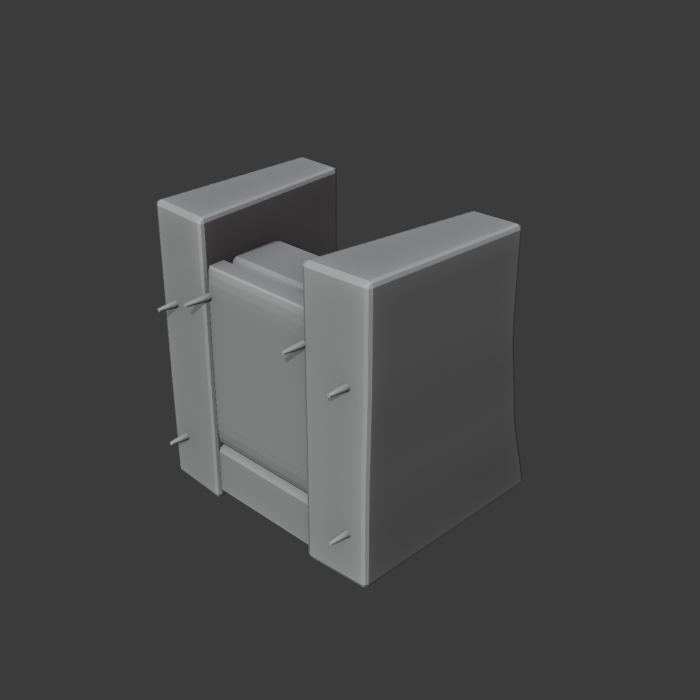

In [27]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

ROOT = Path("/kaggle/working/MeshCoder"); PY = ROOT / ".venv/bin/python"; SCRIPT = ROOT / "render.py"; OUT = ROOT / "res/preview.png"

SCRIPT.write_text(r'''
import bpy, math
from mathutils import Vector
from pathlib import Path

ROOT = Path("/kaggle/working/MeshCoder")
bpy.ops.wm.open_mainfile(filepath=str(ROOT / "res/result.blend"))

objs = [o for o in bpy.context.scene.objects if o.type in {"MESH","CURVE"}]
assert objs, "场景里没有可渲染模型"

pts = [o.matrix_world @ Vector(c) for o in objs for c in o.bound_box]
mn = Vector((min(p.x for p in pts), min(p.y for p in pts), min(p.z for p in pts)))
mx = Vector((max(p.x for p in pts), max(p.y for p in pts), max(p.z for p in pts)))
center = (mn + mx) / 2; size = max(mx - mn)

bpy.ops.object.camera_add(location=center + Vector((size*2.2, -size*2.2, size*1.6)))
cam = bpy.context.object; cam.data.lens = 55
cam.rotation_euler = (center - cam.location).to_track_quat("-Z", "Y").to_euler()
bpy.context.scene.camera = cam

bpy.ops.object.light_add(type="AREA", location=center + Vector((size*2, -size*2, size*3)))
bpy.context.object.data.energy = 1200; bpy.context.object.data.shape = "DISK"; bpy.context.object.data.size = size*3

bpy.ops.object.light_add(type="AREA", location=center + Vector((-size*2, size, size)))
bpy.context.object.data.energy = 700; bpy.context.object.data.size = size*2

scene = bpy.context.scene
scene.render.engine = "BLENDER_WORKBENCH"
scene.render.resolution_x = scene.render.resolution_y = 700
scene.render.resolution_percentage = 100
scene.render.image_settings.file_format = "PNG"
scene.render.filepath = str(ROOT / "res/preview.png")
scene.display.shading.light = "STUDIO"
scene.display.shading.show_shadows = True
scene.display.shading.show_cavity = True

bpy.ops.render.render(write_still=True)
print("✅", scene.render.filepath, "objects:", len(objs))
''', encoding="utf-8")

subprocess.run([str(PY), str(SCRIPT)], check=True)
display(Image(filename=str(OUT), width=700))

## 3. 顺便还能导出 result.blend / result.glb

In [26]:
from pathlib import Path

for p in Path("/kaggle/working/MeshCoder/res").glob("*"):
    print(f"{p.name:25} {p.stat().st_size/1024/1024:.2f} MB")

result.glb                0.44 MB
result.blend              1.15 MB
code.py                   0.00 MB
